# 쿨링 샴푸 상품 분석

저는 계절과 상관없이 쿨링감을 찾는 사람입니다.  
한겨울에도 두피가 답답하면 쿨링 샴푸를 찾고, 여름이 오면 더 강한 쿨링 제품을 둘러보게 됩니다.

처음에는 “가장 시원한 제품이 좋은 제품 아닐까?”라고 생각했습니다.  
하지만 리뷰를 읽다 보니 쿨링감만큼 자주 등장하는 고민이 있었습니다.  
바로 **자극감**, **민감한 두피**, **사용 후 불편함**에 대한 이야기였습니다.

이번 노트북에서는 리뷰 분석에 앞서,  
올리브영 `쿨링 샴푸` 검색 결과에 나타난 상품 자체의 구조를 먼저 살펴봅니다.


## 현재 노트북의 범위

전체 프로젝트 중 이 노트북은 상품 데이터 분석 파트를 담당합니다.

- **3-1. 상품 데이터 구조 확인**
- **4-1. 상품 데이터 전처리**
- **5-1. 상품 EDA**
  - 브랜드별 상품 수
  - 가격 분포
  - 상품명 키워드 일부


## 데이터 설명

이번 분석에는 올리브영 온라인몰에서 `쿨링 샴푸` 키워드로 검색한 상품 목록 데이터를 사용합니다.  
상품은 `리뷰 많은 순`으로 정렬된 검색 결과를 기준으로 수집했습니다.

- **출처**: [올리브영 온라인몰 `쿨링 샴푸` 검색 결과](https://www.oliveyoung.co.kr/store/search/getSearchMain.do?query=%EC%BF%A8%EB%A7%81%20%EC%83%B4%ED%91%B8)
- **정렬 기준**: 리뷰 많은 순
- **분석 단위**: 상품 1개 = 1행
- **주요 컬럼**: `리뷰순위`, `브랜드`, `상품명`, `가격`

### 컬럼 메모

주요 분석 컬럼은 **굵게** 표시했습니다.

- **`리뷰순위`**: 리뷰 많은 순 기준의 전체 상품 순위
- **`브랜드`**: 상품의 브랜드명
- **`상품명`**: 올리브영에 표시된 상품명
- **`가격`**: 크롤링 당시 화면에 표시된 상품 가격
- `페이지`: 검색 결과에서 상품이 수집된 페이지 번호
- `정렬`: 상품 수집 당시 적용된 정렬 기준
- `상품URL`: 상품 상세 페이지 URL


## 1. 라이브러리 불러오기

데이터 처리와 시각화에 필요한 기본 라이브러리를 불러옵니다.  
그래프에서 한글이 깨지지 않도록 폰트 설정도 함께 적용합니다.


In [1]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정
import matplotlib.font_manager as fm


In [2]:
# 출력 옵션 설정
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.2f}".format)


In [3]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


## 2. 데이터 불러오기

크롤링 단계에서 저장한 상품 목록 데이터를 불러옵니다.  
먼저 상위 행을 확인해 상품 정보가 의도한 형태로 저장되었는지 가볍게 점검합니다.


In [4]:
# 상품 데이터 불러오기
df = pd.read_csv("data/oliveyoung_cooling_shampoo_products.csv")

df.head()


,리뷰순위,페이지,정렬,브랜드,상품명,가격,상품URL
0,1,1,리뷰 많은 순,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000018...
1,2,1,리뷰 많은 순,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),"6,400원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000016...
2,3,1,리뷰 많은 순,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,"5,000원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000011...
3,4,1,리뷰 많은 순,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),"26,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000020...
4,5,1,리뷰 많은 순,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),"25,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000015...


In [5]:
# 데이터 크기 확인
print(f"상품 {df.shape[0]}개, 컬럼 {df.shape[1]}개")


상품 43개, 컬럼 7개


## 3. 상품 데이터 구조 확인

정제에 앞서 원본 데이터의 구조와 값의 형태를 확인합니다.  
컬럼 구성, 데이터 타입, 결측치, 중복 여부를 살펴보고 이후 전처리 단계에서 처리할 부분을 찾습니다.


In [6]:
# 컬럼 확인
df.columns


Index(['리뷰순위', '페이지', '정렬', '브랜드', '상품명', '가격', '상품URL'], dtype='object')

In [7]:
# 데이터 타입 및 결측치 개요 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   리뷰순위    43 non-null     int64 
 1   페이지     43 non-null     int64 
 2   정렬      43 non-null     object
 3   브랜드     43 non-null     object
 4   상품명     43 non-null     object
 5   가격      43 non-null     object
 6   상품URL   43 non-null     object
dtypes: int64(2), object(5)
memory usage: 2.5+ KB


In [8]:
# 컬럼별 결측치 확인
df.isna().sum()


리뷰순위     0
페이지      0
정렬       0
브랜드      0
상품명      0
가격       0
상품URL    0
dtype: int64

In [9]:
# 전체 컬럼의 기초 통계 확인
# 숫자형 컬럼: 평균, 표준편차, 최솟값, 최댓값 등 / 문자형 컬럼: 고유값 수, 최빈값, 최빈값 빈도 등
df.describe(include="all")


,리뷰순위,페이지,정렬,브랜드,상품명,가격,상품URL
count,43.00,43.00,43,43,43,43,43
unique,NaN,NaN,1,29,43,40,43
top,NaN,NaN,리뷰 많은 순,달리프,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"9,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000018...
freq,NaN,NaN,43,5,1,2,1
mean,22.00,1.44,NaN,NaN,NaN,NaN,NaN
std,12.56,0.50,NaN,NaN,NaN,NaN,NaN
min,1.00,1.00,NaN,NaN,NaN,NaN,NaN
25%,11.50,1.00,NaN,NaN,NaN,NaN,NaN
50%,22.00,1.00,NaN,NaN,NaN,NaN,NaN
75%,32.50,2.00,NaN,NaN,NaN,NaN,NaN


In [10]:
# 상품명 기준 중복 확인
print("전체 상품 수:", len(df))
print("고유 상품명 수:", df["상품명"].nunique())
print("상품명 기준 중복 수:", df.duplicated("상품명").sum())


전체 상품 수: 43
고유 상품명 수: 43
상품명 기준 중복 수: 0


In [11]:
# 가격 컬럼 원본 형태 확인
df["가격"].head(10)


0     5,950원~
1     6,400원~
2     5,000원~
3    26,900원~
4    25,900원~
5     16,900원
6     14,900원
7     26,900원
8    17,900원~
9    11,900원~
Name: 가격, dtype: object

### 구조 확인 결과
상품 데이터의 기본 구조를 확인한 결과는 다음과 같습니다.

- 전체 상품 데이터는 총 **43개 행**으로 구성되어 있습니다.
- `상품명`은 모두 고유한 값으로 확인되어, 상품명 기준 중복은 없습니다.
- `가격` 컬럼은 `5,950원~`처럼 문자와 기호가 포함된 문자열 형태로 저장되어 있습니다.
- 따라서 이후 전처리 단계에서는 `가격` 컬럼을 숫자형으로 변환해 분석에 사용할 예정입니다.


## 4. 상품 데이터 전처리

원본 데이터를 분석에 사용하기 좋은 형태로 정리합니다.  
이번 단계에서는 필요한 컬럼을 선택하고, 텍스트 공백 정리와 가격 숫자형 변환을 진행합니다.


In [12]:
# 원본 데이터 보존을 위해 복사본 생성
products = df.copy()
products.head()


,리뷰순위,페이지,정렬,브랜드,상품명,가격,상품URL
0,1,1,리뷰 많은 순,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000018...
1,2,1,리뷰 많은 순,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),"6,400원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000016...
2,3,1,리뷰 많은 순,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,"5,000원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000011...
3,4,1,리뷰 많은 순,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),"26,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000020...
4,5,1,리뷰 많은 순,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),"25,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000015...


In [13]:
# 분석에 사용할 컬럼 선택
use_cols = ["리뷰순위", "브랜드", "상품명", "가격", "상품URL"] # 정렬은 모두 리뷰많은순으로 동일하고 페이지는 리뷰순위가 있으니 필요X

products = products[use_cols].copy()
products.head()


,리뷰순위,브랜드,상품명,가격,상품URL
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),"5,950원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000018...
1,2,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),"6,400원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000016...
2,3,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,"5,000원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000011...
3,4,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),"26,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000020...
4,5,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),"25,900원~",https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo=A00000015...


In [14]:
# 공백 정리 전 상품명 기준 중복 확인
before_strip_duplicates = products.duplicated("상품명").sum()

print(f"공백 정리 전 상품명 기준 중복 수: {before_strip_duplicates}")


공백 정리 전 상품명 기준 중복 수: 0


In [15]:
# 텍스트 컬럼 앞뒤 공백 여부 확인
for col in ["브랜드", "상품명"]:
    before = products[col].astype(str)
    after = before.str.strip()

    print(col, "앞뒤 공백 있는 행 수:", (before != after).sum())


브랜드 앞뒤 공백 있는 행 수: 0
상품명 앞뒤 공백 있는 행 수: 0


In [16]:
# 텍스트 컬럼 앞뒤 공백 제거
for col in ["브랜드", "상품명"]:
    products[col] = products[col].astype(str).str.strip()


In [17]:
# 공백 정리 후 상품명 기준 중복 재확인
# 공백 여부를 확인한 결과, 브랜드명과 상품명 모두 앞뒤 공백 후에도 중복 X -> 별도의 중복 제거 X
after_strip_duplicates = products.duplicated("상품명").sum()

print(f"공백 정리 후 상품명 기준 중복 수: {after_strip_duplicates}")


공백 정리 후 상품명 기준 중복 수: 0


In [18]:
# 가격 컬럼 숫자형 변환
# 변환 검증을 위해 원본 문자열 가격은 잠시 가격_원본으로 보존합니다.
products["가격_원본"] = products["가격"]

products["가격"] = (
    products["가격_원본"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("원~", "", regex=False)
    .str.replace("원", "", regex=False)
    .str.replace("~", "", regex=False)
    .str.strip()
)

products["가격"] = pd.to_numeric(products["가격"], errors="coerce")

products[["가격_원본", "가격"]].head()


,가격_원본,가격
0,"5,950원~",5950
1,"6,400원~",6400
2,"5,000원~",5000
3,"26,900원~",26900
4,"25,900원~",25900


In [19]:
# 가격 컬럼이 모두 숫자형으로 변환되었는지 확인
print("가격 변환 실패 수:", products["가격"].isna().sum())
print("가격 변환 전후 개수 일치:", products["가격_원본"].count() == products["가격"].count())

print("변환 전 가격 타입:", products["가격_원본"].dtype)
print("변환 후 가격 타입:", products["가격"].dtype)


가격 변환 실패 수: 0
가격 변환 전후 개수 일치: True
변환 전 가격 타입: object
변환 후 가격 타입: int64


### 가격 분포 확인 및 가격대 구간 생성

가격대 구간을 임의로 정하지 않기 위해, 먼저 숫자형 가격 컬럼의 분포를 확인합니다.  
분포를 확인한 뒤 상품 가격을 비교하기 위한 `가격대` 컬럼을 생성합니다.


In [20]:
# 가격 기초 통계 확인
products["가격"].describe()


count        43.00
mean     21,710.93
std      18,188.28
min       3,700.00
25%      10,950.00
50%      16,900.00
75%      26,150.00
max     106,000.00
Name: 가격, dtype: float64

In [21]:
# 가격 분위수 확인
products["가격"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1])


0.00     3,700.00
0.25    10,950.00
0.50    16,900.00
0.75    26,150.00
0.90    37,320.00
1.00   106,000.00
Name: 가격, dtype: float64

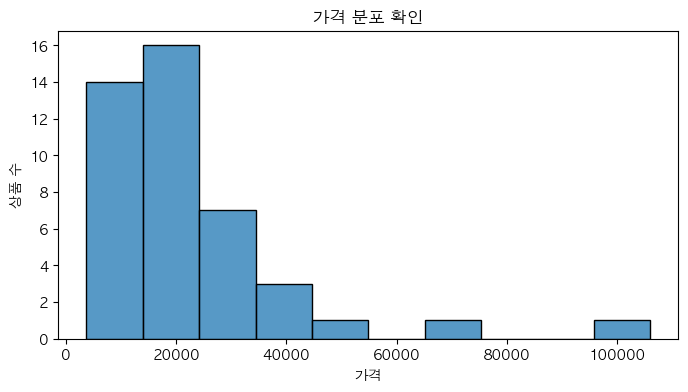

In [22]:
# 가격 분포 간단 확인
# 대부분 상품이 3만원 이하 / 일부 상품이 4~5만원대 / 일부 고가 상품이 오른쪽 꼬리처럼 분포

plt.figure(figsize=(8, 4))
sns.histplot(products["가격"], bins=10)

plt.title("가격 분포 확인")
plt.xlabel("가격")
plt.ylabel("상품 수")
plt.show()


In [23]:
# 가격대 구간 생성
# 1만원 미만: 가격 < 10,000원
# 1만원대: 10,000원 <= 가격 < 20,000원
# 2만원대: 20,000원 <= 가격 < 30,000원
# 3만원 이상: 30,000원 <= 가격
bins = [0, 10000, 20000, 30000, np.inf]
labels = ["1만원 미만", "1만원대", "2만원대", "3만원 이상"]

products["가격대"] = pd.cut(
    products["가격"],
    bins=bins,
    labels=labels,
    right=False # right=False: 왼쪽 경계 포함, 오른쪽 경계 미포함
)

products["가격대"].value_counts().reindex(labels)


가격대
1만원 미만     9
1만원대      20
2만원대       8
3만원 이상     6
Name: count, dtype: int64

In [24]:
# 가격대 생성 결과 확인
products["가격대"].value_counts().reindex(labels)


가격대
1만원 미만     9
1만원대      20
2만원대       8
3만원 이상     6
Name: count, dtype: int64

In [25]:
# 분석용 컬럼 정리
# 가격 변환 검증이 끝났으므로 원본 가격 문자열과 상품 URL은 EDA 데이터에서 제외합니다.
analysis_cols = ["리뷰순위", "브랜드", "상품명", "가격", "가격대"]
products = products[analysis_cols].copy()

products.head()


,리뷰순위,브랜드,상품명,가격,가격대
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만
1,2,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만
2,3,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만
3,4,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),26900,2만원대
4,5,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),25900,2만원대


### 전처리 결과 확인

전처리가 완료된 상품 데이터를 확인합니다.  
이후 EDA에서는 숫자형 `가격`과 구간형 `가격대`가 포함된 `products` 데이터를 기준으로 분석을 진행합니다.


In [26]:
# 전처리 결과 확인
products.head()


,리뷰순위,브랜드,상품명,가격,가격대
0,1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만
1,2,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만
2,3,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만
3,4,라보에이치,[청량감MAX] 라보에이치 쿨링&노세범샴푸 750ML 기획(+샴푸100ML),26900,2만원대
4,5,클로란,[7월올영픽/지성두피&쿨링] 클로란 아쿠아민트 샴푸 더블 기획 (400ml 2입기획),25900,2만원대


In [27]:
# 전처리 후 데이터 구조 확인
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   리뷰순위    43 non-null     int64   
 1   브랜드     43 non-null     object  
 2   상품명     43 non-null     object  
 3   가격      43 non-null     int64   
 4   가격대     43 non-null     category
dtypes: category(1), int64(2), object(2)
memory usage: 1.7+ KB


In [28]:
# 전처리 결과 요약
preprocessing_summary = pd.DataFrame({
    "항목": [
        "상품 수",
        "브랜드 수",
        "가격 변환 실패 수",
        "상품명 기준 중복 수",
        "가격대 결측 수",
        "가격대 구간 수",
        "최종 컬럼 수",
    ],
    "값": [
        len(products),
        products["브랜드"].nunique(),
        products["가격"].isna().sum(),
        products.duplicated("상품명").sum(),
        products["가격대"].isna().sum(),
        products["가격대"].nunique(),
        products.shape[1],
    ],
})

preprocessing_summary


,항목,값
0,상품 수,43
1,브랜드 수,29
2,가격 변환 실패 수,0
3,상품명 기준 중복 수,0
4,가격대 결측 수,0
5,가격대 구간 수,4
6,최종 컬럼 수,5


In [29]:
# 가격대별 상품 수 확인
# '1만~2만원' 구간에 가장 많은 상품이 분포 -> 중심 가격대가 1만원대에 형성되어 있음을 확인할 수 있습니다.
price_band_counts = (
    products["가격대"]
    .value_counts()
    .reindex(labels)
    .reset_index()
)

price_band_counts.columns = ["가격대", "상품 수"]
price_band_counts


,가격대,상품 수
0,1만원 미만,9
1,1만원대,20
2,2만원대,8
3,3만원 이상,6


### 전처리 요약

**정리 결과**
- 분석에 필요한 상품 컬럼만 선별했습니다.
- 브랜드명과 상품명의 앞뒤 공백을 확인하고 정리했습니다.
- 상품명 기준 중복은 발견되지 않았습니다.
- 문자열 가격을 숫자형 `가격`으로 변환했으며, 변환 실패 값은 없었습니다.

**추가 생성 컬럼**
- `가격`: 숫자형 가격
- `가격대`: 가격 비교를 위한 구간형 변수

**가격대 기준**
- `1만원 미만`: [0, 10,000)
- `1만원대`: [10,000, 20,000)
- `2만원대`: [20,000, 30,000)
- `3만원 이상`: [30,000, ∞)


## 5-1. EDA - 브랜드 분석

전처리된 `products` 데이터를 기준으로 브랜드 노출 구조를 확인합니다.  
브랜드별 상품 수를 단순 집계하는 데서 끝내지 않고, 노출 집중도와 Top3 브랜드의 상품/가격 구성을 함께 살펴봅니다.


### 5-1-1. 브랜드 노출 랭킹 확인

먼저 브랜드별 상품 수와 노출 비율을 집계합니다.  
`노출 비율(%)`과 `누적 비율(%)`을 함께 보면 상위 브랜드가 검색 결과에서 차지하는 비중을 더 쉽게 확인할 수 있습니다.


In [30]:
# 브랜드별 상품 수, 노출 비율, 누적 비율 집계
brand_exposure = (
    products["브랜드"]
    .value_counts()
    .rename_axis("브랜드")
    .reset_index(name="상품 수")
)

brand_exposure["순위"] = range(1, len(brand_exposure) + 1)
brand_exposure["노출 비율(%)"] = (
    brand_exposure["상품 수"] / len(products) * 100
).round(1)
brand_exposure["누적 비율(%)"] = brand_exposure["노출 비율(%)"].cumsum().round(1)

# 노출 규모를 빠르게 해석하기 위한 그룹 라벨
brand_exposure["노출 그룹"] = "기타 브랜드"
brand_exposure.loc[brand_exposure["순위"] <= 3, "노출 그룹"] = "Top3 브랜드"
brand_exposure.loc[brand_exposure["상품 수"] == 1, "노출 그룹"] = "단일 상품 브랜드"

brand_exposure = brand_exposure[
    ["순위", "브랜드", "상품 수", "노출 비율(%)", "누적 비율(%)", "노출 그룹"]
]

brand_exposure


,순위,브랜드,상품 수,노출 비율(%),누적 비율(%),노출 그룹
0,1,달리프,5,11.60,11.60,Top3 브랜드
1,2,온더바디,3,7.00,18.60,Top3 브랜드
2,3,클로란,3,7.00,25.60,Top3 브랜드
3,4,닥터그루트,2,4.70,30.30,기타 브랜드
4,5,폴미첼,2,4.70,35.00,기타 브랜드
5,6,라보에이치,2,4.70,39.70,기타 브랜드
6,7,아베다,2,4.70,44.40,기타 브랜드
7,8,려,2,4.70,49.10,기타 브랜드
8,9,닥터포헤어,2,4.70,53.80,기타 브랜드
9,10,디밤비,1,2.30,56.10,단일 상품 브랜드


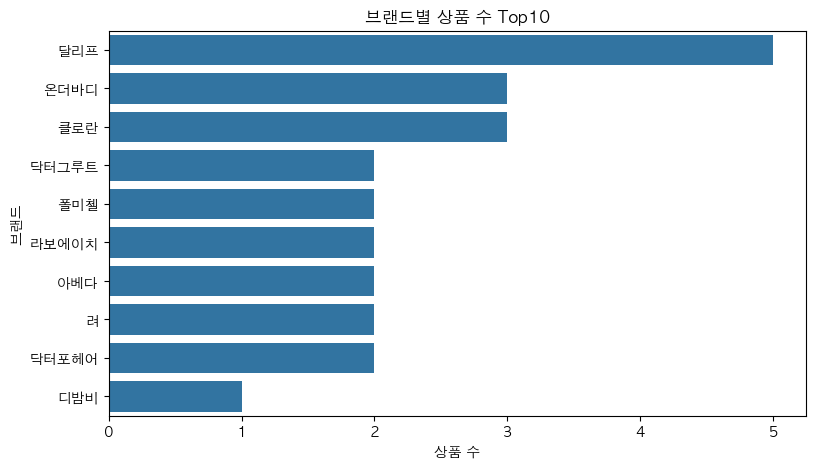

In [31]:
# 브랜드 노출 랭킹 Top10 시각화
# 전체 브랜드가 많기 때문에 그래프는 상위 10개 브랜드만 표시합니다.
brand_exposure_top10 = brand_exposure.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=brand_exposure_top10,
    x="상품 수",
    y="브랜드"
)

plt.title("브랜드별 상품 수 Top10")
plt.xlabel("상품 수")
plt.ylabel("브랜드")
plt.show()


### 5-1-2. 브랜드 노출 집중도 확인

다음으로 검색 결과가 소수 브랜드에 집중되어 있는지 확인합니다.  
전체 브랜드 수, 1위 브랜드 비율, Top3 브랜드 비율을 요약해 브랜드 경쟁 구조를 파악합니다.


In [32]:
# 브랜드 노출 구조 핵심 지표 요약
top1_brand = brand_exposure.iloc[0]
top3_exposure_share = brand_exposure.head(3)["노출 비율(%)"].sum().round(1)
single_sku_brand_count = (brand_exposure["상품 수"] == 1).sum()

brand_exposure_summary = pd.DataFrame({
    "항목": [
        "전체 상품 수",
        "전체 브랜드 수",
        "1위 브랜드",
        "1위 브랜드 노출 비율",
        "Top3 브랜드 노출 비율",
        "상품 1개 브랜드 수",
    ],
    "값": [
        len(products),
        products["브랜드"].nunique(),
        top1_brand["브랜드"],
        f"{top1_brand['노출 비율(%)']}%",
        f"{top3_exposure_share}%",
        single_sku_brand_count,
    ],
})

brand_exposure_summary


,항목,값
0,전체 상품 수,43
1,전체 브랜드 수,29
2,1위 브랜드,달리프
3,1위 브랜드 노출 비율,11.6%
4,Top3 브랜드 노출 비율,25.6%
5,상품 1개 브랜드 수,20


### 5-1-3. 브랜드 분산 구조 확인

브랜드별 상품 수를 한 번 더 묶어 분포를 확인합니다.  
상품이 1개인 브랜드가 많을수록 검색 결과가 여러 브랜드로 넓게 분산되어 있다고 해석할 수 있습니다.


In [33]:
# 상품 수 기준 브랜드 수 집계
# 예: 상품이 1개인 브랜드가 몇 곳인지, 2개인 브랜드가 몇 곳인지 확인합니다.
brand_sku_count_distribution = (
    brand_exposure["상품 수"]
    .value_counts()
    .sort_index(ascending=False)
    .rename_axis("브랜드별 상품 수")
    .reset_index(name="브랜드 수")
)

brand_sku_count_distribution["브랜드 비율(%)"] = (
    brand_sku_count_distribution["브랜드 수"]
    / brand_sku_count_distribution["브랜드 수"].sum()
    * 100
).round(1)

brand_sku_count_distribution


,브랜드별 상품 수,브랜드 수,브랜드 비율(%)
0,5,1,3.40
1,3,2,6.90
2,2,6,20.70
3,1,20,69.00


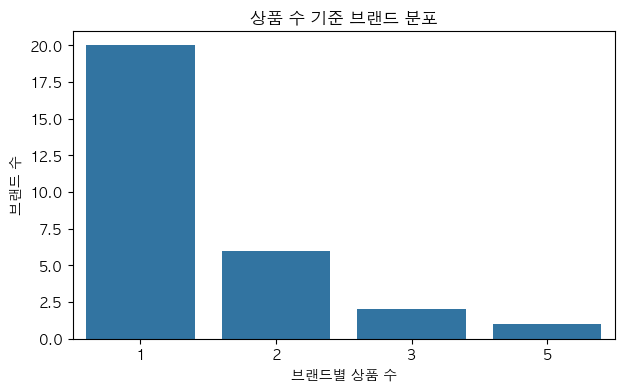

In [34]:
# 브랜드 분산 구조 시각화
plt.figure(figsize=(7, 4))

sns.barplot(
    data=brand_sku_count_distribution,
    x="브랜드별 상품 수",
    y="브랜드 수"
)

plt.title("상품 수 기준 브랜드 분포")
plt.xlabel("브랜드별 상품 수")
plt.ylabel("브랜드 수")
plt.show()


### 5-1-4. Top3 브랜드 라인업 확인

상품 수 기준 상위 3개 브랜드를 따로 살펴봅니다.  
상품명과 가격대를 함께 보면 각 브랜드가 어떤 라인업으로 검색 결과에 노출되는지 비교할 수 있습니다.


In [35]:
# 상품 수 기준 Top3 브랜드 추출
top3_brand_names = brand_exposure.head(3)["브랜드"].tolist()

top3_brand_names


['달리프', '온더바디', '클로란']

In [36]:
# Top3 브랜드의 상품 라인업 확인
top3_brand_lineup = (
    products[products["브랜드"].isin(top3_brand_names)]
    .sort_values(["브랜드", "가격"])
    [["브랜드", "상품명", "가격", "가격대"]]
)

top3_brand_lineup


,브랜드,상품명,가격,가격대
17,달리프,[노세범/쿨링]달리프 쿨링 드라이샴푸 200ml,10900,1만원대
9,달리프,[쿨링감UP/탈모증상완화] 달리프 애플민트 쿨링 샴푸 500ml,11900,1만원대
16,달리프,달리프 오리지널 퍼퓸 드라이샴푸 200ml (노세범/유분순삭),16000,1만원대
15,달리프,달리프 쿨링 드라이 샴푸 200ml*2개,16800,1만원대
10,달리프,[쿨링감UP/탈모완화]달리프 애플민트 쿨링 샴푸 더블기획 (500ml+500ml),19800,1만원대
2,온더바디,[초특가] 온더바디 발을씻자 코튼 풋샴푸 385ml 레몬/자몽/복숭아/쿨링/비누향 5종 택1,5000,1만원 미만
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레몬/자몽/쿨링/비누향),5950,1만원 미만
1,온더바디,[NEW 2세대] 온더바디 발을씻자 코튼 풋샴푸 대용량 510ml 4종 택1(복숭아/레몬/쿨링/자몽),6400,1만원 미만
11,클로란,[7월 올영픽/지성두피&쿨링] 클로란 드라이샴푸 150ml 2종 (쿨세범/노세범),9900,1만원 미만
5,클로란,[지성두피 & 쿨링] 클로란 아쿠아민트 딥클렌징 쿨링 샴푸 400ml,16900,1만원대


### 5-1-5. Top3 브랜드 가격 포지션 확인

Top3 브랜드의 평균가격과 가격 범위를 비교합니다.  
브랜드별로 합리적 가격대 중심인지, 고가 상품까지 포함하는지 확인합니다.


In [37]:
# Top3 브랜드별 가격 요약
top3_brand_price_position = (
    products[products["브랜드"].isin(top3_brand_names)]
    .groupby("브랜드")
    .agg(
        상품수=("상품명", "count"),
        평균가격=("가격", "mean"),
        최저가격=("가격", "min"),
        최고가격=("가격", "max"),
    )
    .round(0)
    .reset_index()
)

top3_brand_price_position


,브랜드,상품수,평균가격,최저가격,최고가격
0,달리프,5,"15,080.00",10900,19800
1,온더바디,3,"5,783.00",5000,6400
2,클로란,3,"17,567.00",9900,25900


In [38]:
# Top3 브랜드별 가격대 구성 확인
top3_brand_price_band = (
    products[products["브랜드"].isin(top3_brand_names)]
    .groupby(["브랜드", "가격대"], observed=False)
    .size()
    .reset_index(name="상품 수")
)

top3_brand_price_band


,브랜드,가격대,상품 수
0,달리프,1만원 미만,0
1,달리프,1만원대,5
2,달리프,2만원대,0
3,달리프,3만원 이상,0
4,온더바디,1만원 미만,3
5,온더바디,1만원대,0
6,온더바디,2만원대,0
7,온더바디,3만원 이상,0
8,클로란,1만원 미만,1
9,클로란,1만원대,1


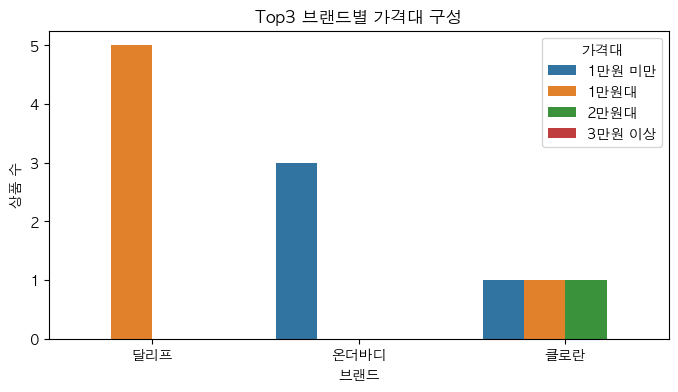

In [39]:
# Top3 브랜드별 가격대 구성 시각화
plt.figure(figsize=(8, 4))

sns.barplot(
    data=top3_brand_price_band,
    x="브랜드",
    y="상품 수",
    hue="가격대"
)

plt.title("Top3 브랜드별 가격대 구성")
plt.xlabel("브랜드")
plt.ylabel("상품 수")
plt.legend(title="가격대")
plt.show()


### 5-1-6. Top3 브랜드 외부 맥락 메모

상위 3개 브랜드의 기본 성격을 함께 정리합니다.  
이 정보는 이후 가격대와 상품명 키워드를 마케팅 관점에서 해석할 때 참고 기준으로 사용합니다.

| 브랜드 | 브랜드 성격 | 해석 포인트 |
|---|---|---|
| 달리프 | 헤어케어 중심 브랜드 | 검색 결과 내 라인업 노출이 가장 강함 |
| 온더바디 | 생활뷰티/바디케어 기반 대중 브랜드 | 접근성, 가격 경쟁력, 사용 편의성 중심 해석 가능 |
| 클로란 | 보태니컬·더모 헤어케어 브랜드 | 성분, 두피 케어, 전문성 중심 해석 가능 |


### 5-1-7. 브랜드 분석 요약

- 검색 결과에는 총 <b>29개 브랜드</b>가 포함되어 있습니다.
- 상품 수 기준 1위 브랜드는 <b>달리프</b>이며, 전체 상품의 <b>11.6%</b>를 차지합니다.
- Top3 브랜드의 노출 비율은 약 <b>25.6%</b>로, 상위 브랜드가 일부 존재하지만 압도적 집중 구조는 아닙니다.
- 브랜드 노출 규모는 <b>달리프 > 온더바디 = 클로란</b> 순으로 나타났습니다.
- 평균 가격 기준으로는 <b>클로란 > 달리프 > 온더바디</b> 순으로, Top3 브랜드 안에서도 가격 포지션 차이가 확인됩니다.
- 상품이 1개만 포함된 브랜드가 <b>20곳</b>으로, 전체적으로는 여러 브랜드가 함께 경쟁하는 분산형 구조에 가깝습니다.

## 5-2. EDA - 가격 분석

상품 가격이 어떤 범위에 분포하는지 살펴봅니다.  
가격 분석은 `쿨링 샴푸` 검색 결과의 중심 가격대와 가격 포지션을 파악하기 위한 단계입니다.


### 5-2-1. 가격 기초 통계 확인

먼저 숫자형으로 정리한 `가격` 컬럼의 기초 통계를 확인합니다.  
평균, 중앙값, 최저가, 최고가를 함께 보면 전체 가격 범위와 중심 가격대를 빠르게 파악할 수 있습니다.


In [40]:
# 가격 기초 통계 요약
price_overview = pd.DataFrame({
    "항목": [
        "상품 수",
        "평균가격",
        "중앙값",
        "최저가격",
        "최고가격",
    ],
    "값": [
        products["가격"].count(),
        round(products["가격"].mean()),
        round(products["가격"].median()),
        products["가격"].min(),
        products["가격"].max(),
    ],
})

price_overview


,항목,값
0,상품 수,43
1,평균가격,21711
2,중앙값,16900
3,최저가격,3700
4,최고가격,106000


In [41]:
# 가격 분위수 확인
# 가격이 어느 구간에 많이 모여 있는지 보기 위해 분위수를 확인합니다.
price_quantiles = (
    products["가격"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 1])
    .reset_index()
)

price_quantiles.columns = ["분위수", "가격"]
price_quantiles["가격"] = price_quantiles["가격"].round(0).astype(int)

price_quantiles


,분위수,가격
0,0.00,3700
1,0.25,10950
2,0.50,16900
3,0.75,26150
4,0.90,37320
5,1.00,106000


### 5-2-2. 가격 분포 확인

히스토그램으로 전체 가격 분포를 확인합니다.  
상품이 어느 가격대에 몰려 있는지, 일부 고가 상품이 분포에 영향을 주는지 살펴봅니다.


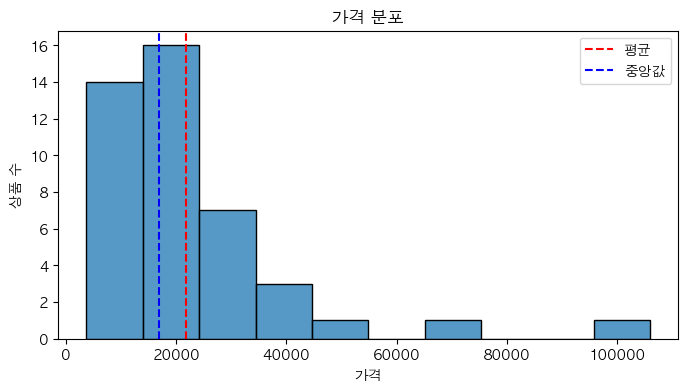

In [42]:
# 가격 분포 시각화
plt.figure(figsize=(8, 4))

sns.histplot(
    data=products,
    x="가격",
    bins=10
)

plt.axvline(products["가격"].mean(), color="red", linestyle="--", label="평균")
plt.axvline(products["가격"].median(), color="blue", linestyle="--", label="중앙값")

plt.title("가격 분포")
plt.xlabel("가격")
plt.ylabel("상품 수")
plt.legend()
plt.show()


### 5-2-3. 가격대별 상품 수 확인

전처리 단계에서 만든 `가격대` 컬럼을 기준으로 상품 수와 비율을 확인합니다.  
이를 통해 검색 결과의 중심 가격대가 어디에 형성되어 있는지 볼 수 있습니다.


In [43]:
# 가격대별 상품 수와 비율 확인
price_band_share = (
    products["가격대"]
    .value_counts()
    .reindex(labels)
    .reset_index()
)

price_band_share.columns = ["가격대", "상품 수"]
price_band_share["비율(%)"] = (
    price_band_share["상품 수"] / price_band_share["상품 수"].sum() * 100
).round(1)

price_band_share


,가격대,상품 수,비율(%)
0,1만원 미만,9,20.90
1,1만원대,20,46.50
2,2만원대,8,18.60
3,3만원 이상,6,14.00


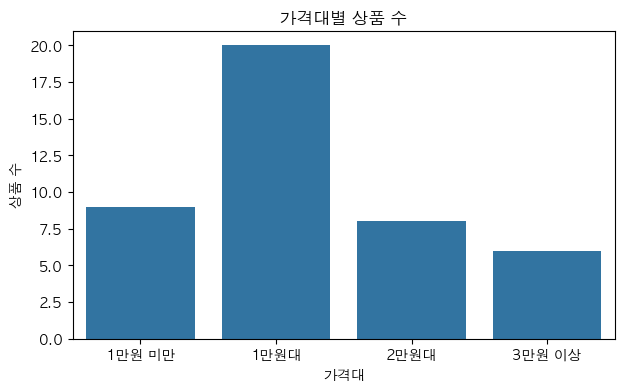

In [44]:
# 가격대별 상품 수 시각화
plt.figure(figsize=(7, 4))

sns.barplot(
    data=price_band_share,
    x="가격대",
    y="상품 수"
)

plt.title("가격대별 상품 수")
plt.xlabel("가격대")
plt.ylabel("상품 수")
plt.show()


### 5-2-4. 가격대별 브랜드 구성 확인

가격대별로 어떤 브랜드가 포함되어 있는지 확인합니다.  
같은 `쿨링 샴푸` 검색 결과 안에서도 브랜드마다 접근하는 가격 포지션이 다른지 살펴보기 위한 단계입니다.


In [45]:
# 가격대별 브랜드 구성 확인
price_band_brand_counts = (
    products
    .groupby(["가격대", "브랜드"], observed=False)
    .size()
    .reset_index(name="상품 수")
    .sort_values(["가격대", "상품 수"], ascending=[True, False])
)

price_band_brand_counts


,가격대,브랜드,상품 수
21,1만원 미만,온더바디,3
8,1만원 미만,동구밭,1
12,1만원 미만,려,1
19,1만원 미만,아리얼,1
23,1만원 미만,쿤달,1
...,...,...,...
109,3만원 이상,원오세븐,0
110,3만원 이상,쿤달,0
111,3만원 이상,클로란,0
112,3만원 이상,톤28,0


In [46]:
# 가격대별 상품 수 Top 브랜드 확인
# 가격대마다 상품 수가 많은 브랜드를 최대 5개씩 확인합니다.
price_band_top_brands = (
    price_band_brand_counts
    .groupby("가격대", observed=False)
    .head(5)
    .reset_index(drop=True)
)

price_band_top_brands


,가격대,브랜드,상품 수
0,1만원 미만,온더바디,3
1,1만원 미만,동구밭,1
2,1만원 미만,려,1
3,1만원 미만,아리얼,1
4,1만원 미만,쿤달,1
5,1만원대,달리프,5
6,1만원대,닥터그루트,2
7,1만원대,나인밀라,1
8,1만원대,닥터바이오,1
9,1만원대,닥터방기원,1


### 5-2-5. 가격 분석 요약

- 전체 상품의 평균 가격은 <b>21,711원</b>, 중앙값은 <b>16,900원</b>으로 확인되었습니다.
- 가격대별로는 <b>1만원대 상품이 20개(46.5%)</b>로 가장 많아, 검색 결과의 중심 가격대는 1만원대에 형성되어 있습니다.
- <b>1만원 미만 상품은 9개(20.9%)</b>, <b>2만원대 상품은 8개(18.6%)</b>, <b>3만원 이상 상품은 6개(14.0%)</b>로 나타났습니다.
- 최고가는 <b>106,000원</b>으로, 일부 고가 상품이 평균 가격을 끌어올리는 구조입니다.
- 따라서 `쿨링 샴푸` 검색 결과는 <b>1만원대 중심의 대중 가격대</b>가 주류이지만, 저가 상품부터 프리미엄 상품까지 함께 노출되는 가격 폭이 넓은 시장으로 볼 수 있습니다.
- 마케팅 관점에서는 <b>1만원대가 가장 치열한 경쟁 구간</b>이며, 고가 상품은 기능성, 브랜드 신뢰, 대용량 등의 차별화 포인트가 함께 필요할 가능성이 있습니다.

## 5-3. EDA - 상품명 키워드 분석

브랜드와 가격 구조를 확인한 뒤, 이번에는 상품명에 사용된 표현을 살펴봅니다.  
상품명 키워드는 브랜드가 소비자에게 어떤 기능과 이미지를 강조하는지 보여주는 마케팅 단서로 볼 수 있습니다.


### 5-3-1. 상품명 텍스트 전처리

상품명에서 특수문자를 제거하고 단어 단위로 나눕니다.  
이 단계에서는 브랜드명과 용량 단위처럼 해석에 직접 도움이 적은 표현만 제외하고, `쿨링`, `리필`, `더블`, `대용량`처럼 상품명에서 강조되는 소구 표현은 남겨둡니다.


In [47]:
# 상품명 키워드 추출을 위한 텍스트 전처리
product_name_tokens = (
    products["상품명"]
    .astype(str)
    .str.replace(r"[^가-힣A-Za-z0-9 ]", " ", regex=True)
    .str.split()
    .explode()
    .str.strip()
)

# 상품명 분석에서 제외할 최소 표현
# 쿨링/기획/대용량/리필/더블 등은 브랜드가 강조하는 메시지일 수 있어 제외하지 않습니다.
keyword_stopwords = set(products["브랜드"].unique()) | {
    "샴푸", "ml", "ML", "g", "G", "입", "종", "개", "택1", "NEW",
}

product_name_tokens = product_name_tokens[
    product_name_tokens.notna()
    & (product_name_tokens.str.len() >= 2)
    & (~product_name_tokens.isin(keyword_stopwords))
]

product_name_tokens.head(20)


0     발을씻자
0       코튼
0      풋샴푸
0       리필
0    500ml
0       4종
0       레몬
0       자몽
0       쿨링
0      비누향
1      2세대
1     발을씻자
1       코튼
1      풋샴푸
1      대용량
1    510ml
1       4종
1      복숭아
1       레몬
1       쿨링
Name: 상품명, dtype: object

### 5-3-2. 상품명 주요 키워드 빈도 확인

상품명에 자주 등장하는 단어를 확인합니다.  
반복적으로 등장하는 키워드는 검색 결과에서 브랜드들이 공통적으로 강조하는 제품 특징으로 해석할 수 있습니다.


In [48]:
# 상품명 주요 키워드 빈도 확인
product_keyword_counts = (
    product_name_tokens
    .value_counts()
    .head(20)
    .rename_axis("키워드")
    .reset_index(name="빈도")
)

product_keyword_counts


,키워드,빈도
0,쿨링,35
1,기획,7
2,풋샴푸,5
3,2종,5
4,500ml,5
5,400ml,5
6,지성두피,4
7,드라이샴푸,4
8,올영픽,3
9,케어,3


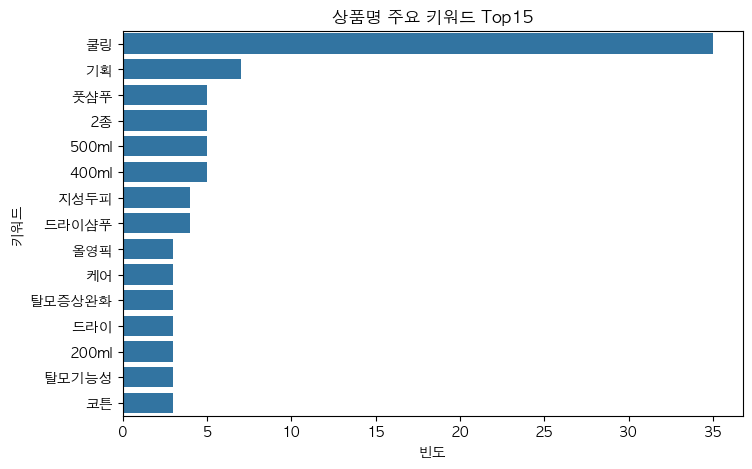

In [49]:
# 상품명 주요 키워드 Top15 시각화
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_keyword_counts.head(15),
    x="빈도",
    y="키워드"
)

plt.title("상품명 주요 키워드 Top15")
plt.xlabel("빈도")
plt.ylabel("키워드")
plt.show()


### 5-3-3. 마케팅 소구 키워드 분류

상품명 키워드를 마케팅 소구 관점에서 묶어 봅니다.  
단어 빈도만 보는 것보다, 어떤 메시지 축이 많이 사용되는지 확인하는 데 목적이 있습니다.


In [50]:
# 마케팅 소구 카테고리별 대표 키워드 정의
appeal_keyword_map = {
    "쿨링/청량감": ["쿨링", "시원", "청량", "민트", "페퍼민트", "아쿠아민트", "프레쉬", "아이스"],
    "두피 진정/케어": ["두피", "진정", "수딩", "케어", "각질", "스크럽", "민감"],
    "유분/노세범": ["노세범", "지성", "유분", "딥클렌징", "클렌징", "냄새"],
    "탈모/기능성": ["탈모", "기능성", "증모", "맥주효모", "바이오틴"],
    "성분/자연 이미지": ["보태니컬", "더모", "비건", "약산성", "말차", "허브", "로즈마리"],
    "구성/혜택": ["기획", "대용량", "더블", "증정", "리필", "세트", "특가"],
}

# 상품명에 각 소구 카테고리의 키워드가 포함되는지 확인
appeal_rows = []

for appeal, keywords in appeal_keyword_map.items():
    pattern = "|".join(keywords)
    matched = products["상품명"].astype(str).str.contains(pattern, case=False, regex=True)

    appeal_rows.append({
        "소구 카테고리": appeal,
        "상품 수": matched.sum(),
        "비율(%)": round(matched.mean() * 100, 1),
        "대표 키워드": ", ".join(keywords[:4]),
    })

appeal_keyword_summary = pd.DataFrame(appeal_rows).sort_values("상품 수", ascending=False)

appeal_keyword_summary


,소구 카테고리,상품 수,비율(%),대표 키워드
0,쿨링/청량감,38,88.40,"쿨링, 시원, 청량, 민트"
1,두피 진정/케어,17,39.50,"두피, 진정, 수딩, 케어"
2,유분/노세범,12,27.90,"노세범, 지성, 유분, 딥클렌징"
5,구성/혜택,12,27.90,"기획, 대용량, 더블, 증정"
3,탈모/기능성,9,20.90,"탈모, 기능성, 증모, 맥주효모"
4,성분/자연 이미지,1,2.30,"보태니컬, 더모, 비건, 약산성"


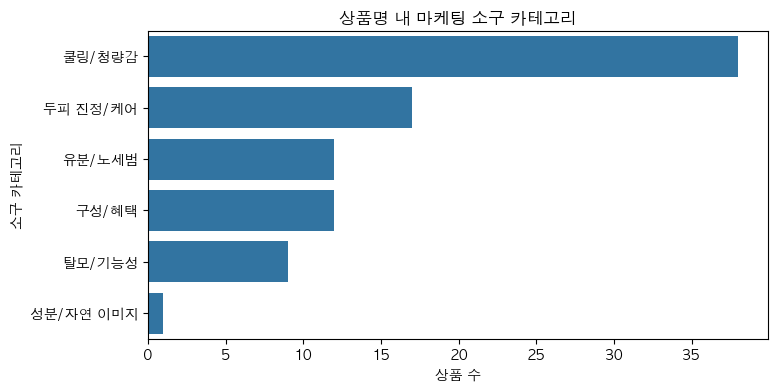

In [51]:
# 마케팅 소구 카테고리별 상품 수 시각화
plt.figure(figsize=(8, 4))

sns.barplot(
    data=appeal_keyword_summary,
    x="상품 수",
    y="소구 카테고리"
)

plt.title("상품명 내 마케팅 소구 카테고리")
plt.xlabel("상품 수")
plt.ylabel("소구 카테고리")
plt.show()


### 5-3-4. 브랜드별 키워드 차이 확인

Top3 브랜드가 어떤 소구 키워드를 사용하는지 비교합니다.  
같은 쿨링 샴푸 카테고리 안에서도 브랜드별 메시지 방향이 다른지 확인할 수 있습니다.


In [52]:
# Top3 브랜드별 마케팅 소구 카테고리 사용 여부 확인
brand_appeal_rows = []

top3_products = products[products["브랜드"].isin(top3_brand_names)].copy()

for brand, brand_df in top3_products.groupby("브랜드"):
    for appeal, keywords in appeal_keyword_map.items():
        pattern = "|".join(keywords)
        matched_count = brand_df["상품명"].astype(str).str.contains(pattern, case=False, regex=True).sum()

        brand_appeal_rows.append({
            "브랜드": brand,
            "소구 카테고리": appeal,
            "상품 수": matched_count,
        })

brand_appeal_summary = pd.DataFrame(brand_appeal_rows)
brand_appeal_summary = brand_appeal_summary[brand_appeal_summary["상품 수"] > 0]

brand_appeal_summary


,브랜드,소구 카테고리,상품 수
0,달리프,쿨링/청량감,4
2,달리프,유분/노세범,2
3,달리프,탈모/기능성,2
5,달리프,구성/혜택,1
6,온더바디,쿨링/청량감,3
11,온더바디,구성/혜택,3
12,클로란,쿨링/청량감,3
13,클로란,두피 진정/케어,3
14,클로란,유분/노세범,3
17,클로란,구성/혜택,1


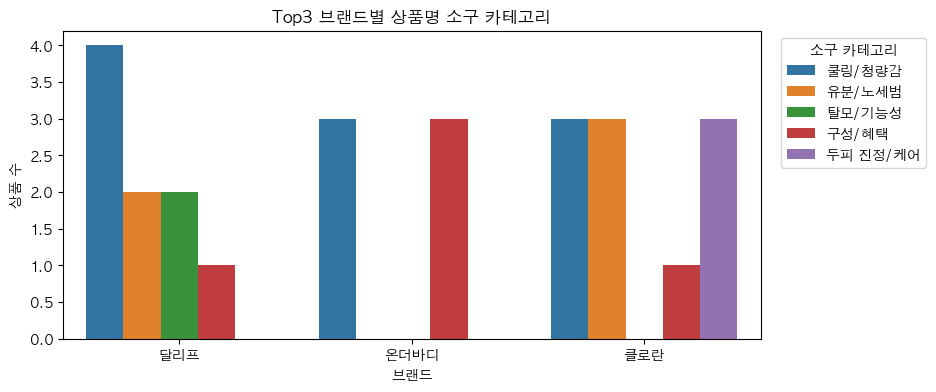

In [53]:
# Top3 브랜드별 소구 카테고리 시각화
plt.figure(figsize=(9, 4))

sns.barplot(
    data=brand_appeal_summary,
    x="브랜드",
    y="상품 수",
    hue="소구 카테고리"
)

plt.title("Top3 브랜드별 상품명 소구 카테고리")
plt.xlabel("브랜드")
plt.ylabel("상품 수")
plt.legend(title="소구 카테고리", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


### 5-3-5. 상품명 키워드 분석 요약

- 상품명에서 가장 많이 등장한 키워드는 <b>쿨링</b>으로, 총 <b>35회</b> 확인되었습니다.
- 마케팅 소구 카테고리 기준으로는 <b>쿨링/청량감</b>이 <b>38개 상품(88.4%)</b>에 포함되어, 검색 결과의 핵심 메시지는 <b>‘시원함’</b>에 가장 강하게 집중되어 있었습니다.
- 그다음으로 <b>두피 진정/케어</b>가 <b>17개 상품(39.5%)</b>, <b>유분/노세범</b>과 <b>구성/혜택</b>이 각각 <b>12개 상품(27.9%)</b>에서 확인되었습니다.
- Top3 브랜드를 비교하면, <b>달리프</b>는 쿨링과 함께 유분/탈모 기능성 메시지가 함께 나타났고, <b>온더바디</b>는 쿨링과 구성/혜택 중심, <b>클로란</b>은 쿨링·두피 케어·유분 관리 메시지가 함께 나타났습니다.
- 따라서 `쿨링 샴푸` 상품명은 단순히 ‘시원함’만 강조하기보다, <b>두피 케어</b>, <b>유분 관리</b>, <b>기획/대용량 혜택</b>을 함께 묶어 소비자에게 전달하는 구조로 볼 수 있습니다.

## 6. 상품 분석 인사이트

상품 데이터 EDA를 통해 브랜드 구성, 가격대, 상품명 소구 포인트를 확인했습니다.  
다만 상품 정보만으로는 소비자가 실제로 어떤 요소에 만족하거나 불편함을 느꼈는지까지 파악하기 어렵습니다.

따라서 다음 단계에서는 리뷰 데이터를 활용해, 상품이 내세우는 메시지와 소비자 경험이 실제로 일치하는지 확인합니다.


### 6-1. 상품 분석 핵심 지표 요약

앞선 브랜드, 가격, 상품명 키워드 분석에서 확인한 핵심 비율을 한 번에 정리합니다.  
이 시각화는 상품 데이터에서 확인한 시장 구조를 요약하고, 리뷰 분석으로 넘어갈 기준점을 잡기 위한 용도입니다.


In [54]:
# 상품 분석에서 확인한 핵심 비율 요약
product_insight_summary = pd.DataFrame({
    "분석 축": [
        "Top3 브랜드 노출 비율",
        "1만원대 상품 비율",
        "쿨링/청량감 소구 비율",
        "두피 진정/케어 소구 비율",
    ],
    "비율(%)": [
        top3_exposure_share,
        price_band_share.loc[price_band_share["가격대"] == "1만원대", "비율(%)"].iloc[0],
        appeal_keyword_summary.loc[appeal_keyword_summary["소구 카테고리"] == "쿨링/청량감", "비율(%)"].iloc[0],
        appeal_keyword_summary.loc[appeal_keyword_summary["소구 카테고리"] == "두피 진정/케어", "비율(%)"].iloc[0],
    ],
})

product_insight_summary


,분석 축,비율(%)
0,Top3 브랜드 노출 비율,25.60
1,1만원대 상품 비율,46.50
2,쿨링/청량감 소구 비율,88.40
3,두피 진정/케어 소구 비율,39.50


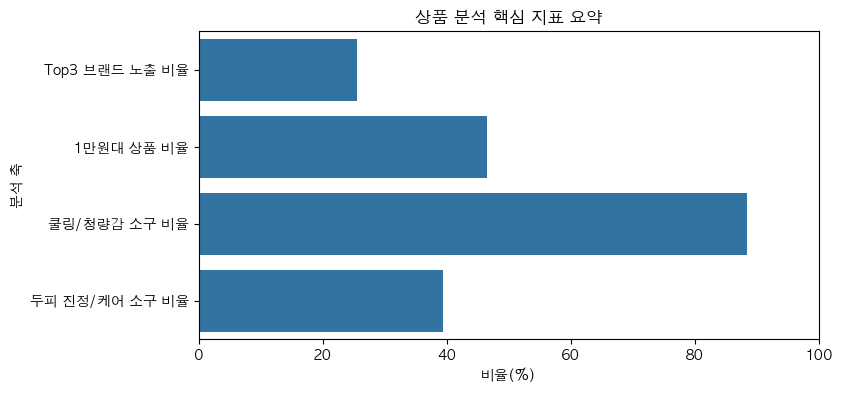

In [55]:
# 상품 분석 핵심 비율 시각화
plt.figure(figsize=(8, 4))

sns.barplot(
    data=product_insight_summary,
    x="비율(%)",
    y="분석 축"
)

plt.title("상품 분석 핵심 지표 요약")
plt.xlabel("비율(%)")
plt.ylabel("분석 축")
plt.xlim(0, 100)
plt.show()


### 6-2. 상품 데이터에서 확인한 점

- Top3 브랜드의 노출 비율은 약 <b>25.6%</b>로, 일부 상위 브랜드가 존재하지만 특정 브랜드가 압도적으로 지배하는 구조는 아니었습니다.
- 가격대는 <b>1만원대 상품</b>이 가장 많아, 대중적인 가격 구간에서 경쟁이 집중되어 있었습니다.
- 상품명에서는 <b>쿨링/청량감</b> 소구가 가장 강하게 나타났고, 그다음으로 <b>두피 진정/케어</b> 메시지가 반복적으로 확인되었습니다.


### 6-3. 상품 데이터만으로는 부족했던 점

상품 데이터에서는 브랜드가 어떤 가격대와 메시지로 제품을 노출하는지는 확인할 수 있었습니다.  
하지만 소비자가 실제로 어떤 제품을 좋게 느꼈는지, 어떤 점에서 불편함을 느꼈는지는 상품 정보만으로 판단하기 어렵습니다.

특히 `쿨링감`이 강하게 강조되고 있었지만, 이것이 실제 만족으로 이어지는지 또는 자극감으로 받아들여지는지는 리뷰를 통해 추가 확인이 필요합니다.


### 6-4. 리뷰 분석으로 이어질 질문

다음 리뷰 분석에서는 아래 질문을 중심으로 소비자 반응을 확인합니다.

- 소비자는 `쿨링감`을 긍정적으로 받아들이는가, 아니면 자극으로 느끼는가?
- `두피 케어`, `유분 관리`, `탈모 기능성` 같은 상품명 소구가 실제 리뷰에서도 언급되는가?
- 가격대별로 만족/불만 포인트가 다르게 나타나는가?
- 브랜드가 강조한 메시지와 소비자가 실제로 언급한 경험 사이에 차이가 있는가?


## 7. 정제 상품 데이터 저장

`05_integrated_marketing_analysis.ipynb`에서는 원본 상품 데이터가 아니라, 이 노트북에서 정리한 상품 데이터를 불러와 사용합니다.  
상품명과 브랜드 공백을 정리하고, 가격을 숫자형으로 변환한 뒤 가격대 컬럼을 추가해 저장합니다.


In [56]:
# 정제 상품 데이터 저장
# 05_integrated_marketing_analysis.ipynb에서는 이 파일을 불러와 리뷰 텍스트 분석 결과와 연결합니다.
cleaned_product_path = "data/oliveyoung_cooling_shampoo_product_cleaned.csv"

product_cleaned = df.copy()
for col in ["브랜드", "상품명"]:
    product_cleaned[col] = product_cleaned[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

product_cleaned["가격"] = (
    product_cleaned["가격"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("원~", "", regex=False)
    .str.replace("원", "", regex=False)
    .str.replace("~", "", regex=False)
    .str.strip()
)
product_cleaned["가격"] = pd.to_numeric(product_cleaned["가격"], errors="coerce")
product_cleaned["가격대"] = pd.cut(product_cleaned["가격"], bins=bins, labels=labels, right=False)

product_cleaned = product_cleaned[["리뷰순위", "페이지", "정렬", "브랜드", "상품명", "가격", "가격대", "상품URL"]].drop_duplicates(["브랜드", "상품명"])
product_cleaned.to_csv(cleaned_product_path, index=False, encoding="utf-8-sig")

print(f"정제 상품 데이터 저장 완료: {cleaned_product_path}")
print(f"저장된 데이터 크기: {product_cleaned.shape[0]:,}행, {product_cleaned.shape[1]:,}컬럼")


정제 상품 데이터 저장 완료: data/oliveyoung_cooling_shampoo_product_cleaned.csv
저장된 데이터 크기: 43행, 8컬럼
